In [1]:
!pip install anthropic reportlab openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.0/932.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.4 MB/s eta 0:00:00


In [2]:
# ── Standard Libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Machine Learning ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# ── AI Agent ─────────────────────────────────────────────────────
import anthropic

print('✅ All libraries loaded successfully!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   sklearn loaded')

✅ All libraries loaded successfully!
   pandas  2.2.2
   numpy   2.0.2
   sklearn loaded


In [3]:
df = pd.read_csv('telecom_churn.csv')

In [4]:
df.shape

(7043, 18)

In [5]:
print('=' * 45)
print('   CHURNSHIELD — Dataset Overview')
print('=' * 45)
print(f'  Rows (Customers) : {df.shape[0]:,}')
print(f'  Columns (Features): {df.shape[1]}')
print(f'  Memory Usage      : {df.memory_usage().sum() / 1024:.1f} KB')
print('=' * 45)

df.head()

   CHURNSHIELD — Dataset Overview
  Rows (Customers) : 7,043
  Columns (Features): 18
  Memory Usage      : 990.6 KB


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Female,0,Yes,No,52,Yes,Yes,No,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),115.28,NaN,No
1,CUST00002,Male,0,Yes,No,15,Yes,Yes,No,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),57.76,862.94,No
2,CUST00003,Male,0,Yes,No,72,Yes,Yes,DSL,No,Yes,Yes,Month-to-month,Yes,Electronic check,39.44,2937.22,No
3,CUST00004,Male,0,No,No,61,Yes,No,DSL,No,No,Yes,Two year,No,Credit card (automatic),116.01,6725.20,No
4,CUST00005,Female,1,Yes,No,21,Yes,Yes,DSL,Yes,No,No,Two year,No,Electronic check,47.61,870.49,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  Contract          7043 non-null   object 
 13  PaperlessBilling  7043 non-null   object 
 14  PaymentMethod     7043 non-null   object 
 15  MonthlyCharges    7043 non-null   float64
 16  TotalCharges      6956 non-null   float64


In [7]:
df.describe().round(2)

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,6956.00
mean,0.17,36.43,67.60,2338.54
std,0.37,20.69,29.11,1764.58
min,0.00,1.00,18.01,19.08
25%,0.00,19.00,42.65,928.82
50%,0.00,36.00,67.04,1930.22
75%,0.00,54.00,92.87,3401.38
max,1.00,72.00,117.99,8526.78


In [8]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


🎯 TARGET VARIABLE — Churn Distribution
----------------------------------------
  Yes | ████████████              24.7% (1,738)
  No  | █████████████████████████████████████ 75.3% (5,305)


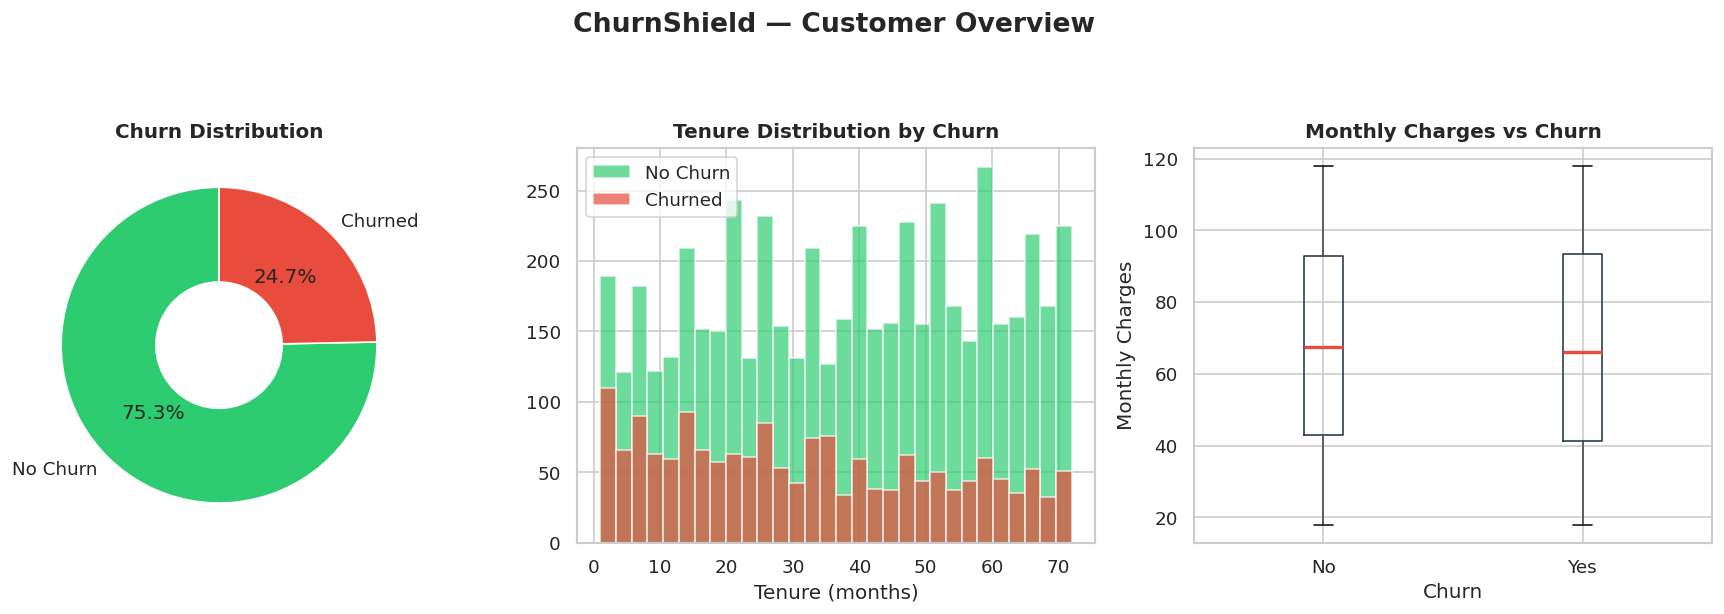

✅ Chart saved to outputs/


In [9]:
# ── Churn Distribution ───────────────────────────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('🎯 TARGET VARIABLE — Churn Distribution')
print('-' * 40)
for label in ['Yes', 'No']:
    bar = '█' * int(churn_pct[label] / 2)
    print(f"  {label:3s} | {bar:<25} {churn_pct[label]:.1f}% ({churn_counts[label]:,})")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ChurnShield — Customer Overview', fontsize=14, fontweight='bold', y =1.05)

# Plot 1: Churn Donut
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_counts, labels=['No Churn','Churned'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.6))
axes[0].set_title('Churn Distribution', fontweight='bold')

# Plot 2: Tenure by Churn
df[df['Churn']=='No']['Tenure'].hist(ax=axes[1], alpha=0.7, color='#2ecc71', label='No Churn', bins=30)
df[df['Churn']=='Yes']['Tenure'].hist(ax=axes[1], alpha=0.7, color='#e74c3c', label='Churned', bins=30)
axes[1].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].legend()

# Plot 3: Monthly Charges Boxplot
df.boxplot(
    column='MonthlyCharges',
    by='Churn',
    ax=axes[2],
    boxprops=dict(color='#2c3e50'),
    medianprops=dict(color='#e74c3c', linewidth=2)
)

axes[2].set_title(
    'Monthly Charges vs Churn',
    fontweight='bold'
)
axes[2].set_xlabel('Churn')
axes[2].set_ylabel('Monthly Charges')

# Remove automatic pandas title
axes[2].get_figure().suptitle('')

# Create your dashboard title again
fig.suptitle(
    'ChurnShield — Customer Overview',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

# Leave space for top title
plt.tight_layout(rect=[0,0,1,0.95])

plt.show()

print('✅ Chart saved to outputs/')

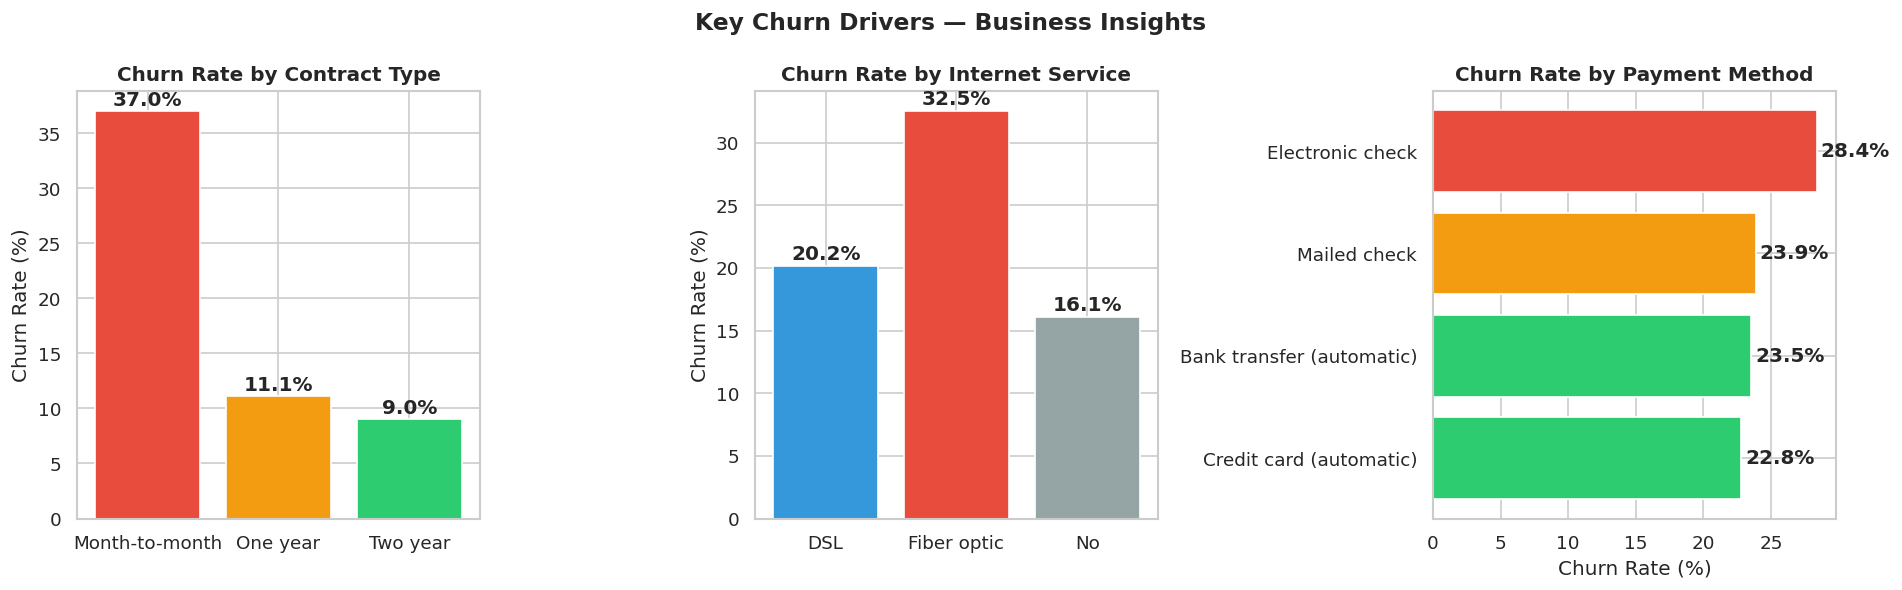

✅ Business insight charts saved!


In [10]:
# ── Churn by Contract Type ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Key Churn Drivers — Business Insights', fontsize=14, fontweight='bold')

# Contract type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').mean() * 100).reset_index()
contract_churn.columns = ['Contract', 'ChurnRate']
bars = axes[0].bar(contract_churn['Contract'], contract_churn['ChurnRate'],
                   color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
for bar, val in zip(bars, contract_churn['ChurnRate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Internet Service
internet_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x=='Yes').mean() * 100).reset_index()
internet_churn.columns = ['Service', 'ChurnRate']
bars2 = axes[1].bar(internet_churn['Service'], internet_churn['ChurnRate'],
                    color=['#3498db','#e74c3c','#95a5a6'])
axes[1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars2, internet_churn['ChurnRate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Payment Method
pay_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x=='Yes').mean() * 100).sort_values(ascending=True)
colors_pay = ['#2ecc71','#2ecc71','#f39c12','#e74c3c']
axes[2].barh(pay_churn.index, pay_churn.values, color=colors_pay)
axes[2].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[2].set_xlabel('Churn Rate (%)')
for i, val in enumerate(pay_churn.values):
    axes[2].text(val + 0.3, i, f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('02_churn_drivers.png', bbox_inches='tight')
plt.show()
print('✅ Business insight charts saved!')

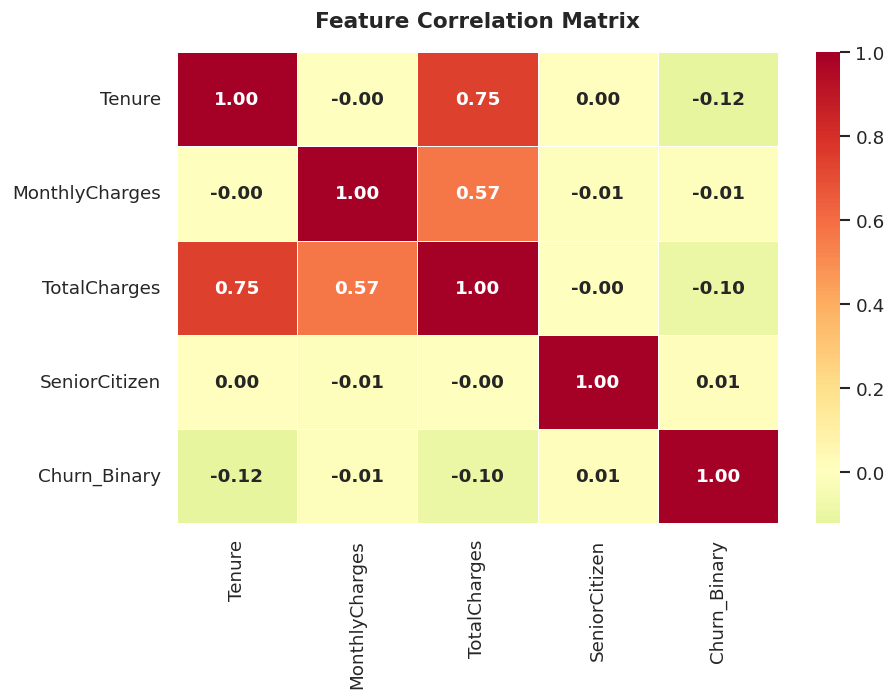

✅ Correlation heatmap saved!


In [11]:
# ── Correlation Heatmap ──────────────────────────────────────────
# Key business metrics
numeric_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
fig, ax = plt.subplots(figsize=(8, 6))

temp = df[numeric_cols].copy()
temp['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)
corr = temp.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('03_correlation.png', bbox_inches='tight')
plt.show()
print('✅ Correlation heatmap saved!')

In [12]:
# ── Check for Missing Values ─────────────────────────────────────
print('🔍 Missing Value Check:')
print('-' * 40)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]
print(missing_report)

print(f'\n  Total missing values: {df.isnull().sum().sum()}')
print(f'  Affected rows       : {df.isnull().any(axis=1).sum()}')

🔍 Missing Value Check:
----------------------------------------
              Missing Count  Missing %
TotalCharges             87       1.24

  Total missing values: 87
  Affected rows       : 87


In [13]:
# ── Clean the Data ───────────────────────────────────────────────
df_clean = df.copy()

# Step 1: Fill missing TotalCharges with median
median_total = df_clean['TotalCharges'].median()
df_clean['TotalCharges'].fillna(median_total, inplace=True)
print(f'✅ Filled {missing["TotalCharges"]} missing TotalCharges with median: ${median_total:,.2f}')

# Step 2: Remove duplicates
dupes = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f'✅ Removed {dupes} duplicate rows (if any)')

# Step 3: Encode target
df_clean['Churn_Binary'] = (df_clean['Churn'] == 'Yes').astype(int)
print(f'✅ Created binary churn column (0=No, 1=Yes)')

# Step 4: Create business features
df_clean['AvgMonthlySpend'] = (df_clean['TotalCharges'] / df_clean['Tenure']).round(2)
df_clean['TenureGroup'] = pd.cut(df_clean['Tenure'],
                                  bins=[0,12,24,48,72],
                                  labels=['0-1yr','1-2yr','2-4yr','4+yr'])
df_clean['ChargeGroup'] = pd.cut(df_clean['MonthlyCharges'],
                                  bins=[0,35,65,90,120],
                                  labels=['Low','Medium','High','Premium'])

print(f'✅ Engineered 3 new features: AvgMonthlySpend, TenureGroup, ChargeGroup')
print(f'\n📊 Clean Dataset Shape: {df_clean.shape}')

✅ Filled 87 missing TotalCharges with median: $1,930.22
✅ Removed 0 duplicate rows (if any)
✅ Created binary churn column (0=No, 1=Yes)
✅ Engineered 3 new features: AvgMonthlySpend, TenureGroup, ChargeGroup

📊 Clean Dataset Shape: (7043, 22)


In [14]:
import os
os.makedirs('../data', exist_ok=True)

conn = sqlite3.connect('../data/churnshield.db')

# Write tables
df_clean.to_sql('customers', conn, if_exists='replace', index=False)
print('✅ Data written to SQLite database: churnshield.db')
print(f'   Table: customers | Rows: {len(df_clean):,} | Columns: {len(df_clean.columns)}')

# Verify
test = pd.read_sql('SELECT COUNT(*) as total FROM customers', conn)
print(f'   Verification: {test["total"][0]:,} rows confirmed in DB ✅')

✅ Data written to SQLite database: churnshield.db
   Table: customers | Rows: 7,043 | Columns: 22
   Verification: 7,043 rows confirmed in DB ✅


In [15]:
# ── SQL Query 1: Business KPIs ───────────────────────────────────
sql_kpis = """
SELECT
    COUNT(*)                                          AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)  AS churned_customers,
    ROUND(AVG(CASE WHEN Churn='Yes' THEN 1.0 ELSE 0 END) * 100, 2) AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 2)                    AS avg_monthly_charges,
    ROUND(AVG(Tenure), 1)                            AS avg_tenure_months,
    ROUND(SUM(TotalCharges), 0)                      AS total_revenue
FROM customers
"""
kpis = pd.read_sql(sql_kpis, conn)
print('📊 BUSINESS KPIs — ChurnShield Dashboard')
print('=' * 50)
for col in kpis.columns:
    val = kpis[col][0]
    print(f'  {col:<30}: {val}')
print('=' * 50)

📊 BUSINESS KPIs — ChurnShield Dashboard
  total_customers               : 7043
  churned_customers             : 1738
  churn_rate_pct                : 24.68
  avg_monthly_charges           : 67.6
  avg_tenure_months             : 36.4
  total_revenue                 : 16434820.0


In [16]:
# ── SQL Query 2: Churn by Contract & Internet ────────────────────
sql_segment = """
SELECT
    Contract,
    InternetService,
    COUNT(*) AS customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
    ROUND(AVG(CASE WHEN Churn='Yes' THEN 1.0 ELSE 0 END)*100, 1) AS churn_rate,
    ROUND(AVG(MonthlyCharges),2) AS avg_charge
FROM customers
GROUP BY Contract, InternetService
ORDER BY churn_rate DESC
"""
segments = pd.read_sql(sql_segment, conn)
print('📋 Churn by Contract × Internet Service:')
print(segments.to_string(index=False))

📋 Churn by Contract × Internet Service:
      Contract InternetService  customers  churned  churn_rate  avg_charge
Month-to-month     Fiber optic       1662      772        46.5       68.56
Month-to-month             DSL       1302      415        31.9       66.42
Month-to-month              No        867      231        26.6       67.16
      One year     Fiber optic        626      111        17.7       68.00
      Two year     Fiber optic        807      123        15.2       69.25
      One year             DSL        506       40         7.9       66.73
      Two year             DSL        584       27         4.6       67.26
      One year              No        317       10         3.2       65.12
      Two year              No        372        9         2.4       68.03


In [17]:
sql_highrisk = """
SELECT
    CustomerID,
    Contract,
    InternetService,
    Tenure,
    MonthlyCharges,
    PaymentMethod,
    TechSupport
FROM customers
WHERE
    Contract = 'Month-to-month'
    AND InternetService = 'Fiber optic'
    AND Tenure < 12
    AND PaymentMethod = 'Electronic check'
ORDER BY MonthlyCharges DESC
LIMIT 15
"""
high_risk_sql = pd.read_sql(sql_highrisk, conn)
print(f'🚨 High-Risk Customer Segment (SQL filter): {len(high_risk_sql)} customers')
print(high_risk_sql.to_string(index=False))

# Export to Excel for Power BI
high_risk_sql.to_excel('/content/high_risk_customers_sql.xlsx', index=False)
print('\n✅ Exported to Excel for Power BI import!')

from google.colab import files

files.download('/content/high_risk_customers_sql.xlsx')

🚨 High-Risk Customer Segment (SQL filter): 15 customers
CustomerID       Contract InternetService  Tenure  MonthlyCharges    PaymentMethod TechSupport
 CUST05854 Month-to-month     Fiber optic       4          115.68 Electronic check         Yes
 CUST06966 Month-to-month     Fiber optic      11          113.74 Electronic check          No
 CUST02644 Month-to-month     Fiber optic       1          113.46 Electronic check          No
 CUST00052 Month-to-month     Fiber optic       4          111.99 Electronic check         Yes
 CUST03779 Month-to-month     Fiber optic       9          111.64 Electronic check          No
 CUST00603 Month-to-month     Fiber optic       1          110.85 Electronic check         Yes
 CUST06525 Month-to-month     Fiber optic       5          109.15 Electronic check         Yes
 CUST00594 Month-to-month     Fiber optic       6          108.67 Electronic check          No
 CUST05344 Month-to-month     Fiber optic       9          107.90 Electronic check       

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# ── SQL Query 4: Revenue at Risk ─────────────────────────────────
sql_revenue = """
SELECT
    TenureGroup,
    COUNT(*) AS customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
    ROUND(AVG(CASE WHEN Churn='Yes' THEN 1.0 ELSE 0 END)*100,1) AS churn_rate,
    ROUND(SUM(CASE WHEN Churn='Yes' THEN MonthlyCharges ELSE 0 END),0) AS monthly_revenue_at_risk
FROM customers
GROUP BY TenureGroup
ORDER BY churn_rate DESC
"""
revenue_risk = pd.read_sql(sql_revenue, conn)
print('💰 Revenue at Risk by Tenure Group:')
print(revenue_risk.to_string(index=False))
total_at_risk = revenue_risk['monthly_revenue_at_risk'].sum()
print(f'\n  Total Monthly Revenue at Risk: ${total_at_risk:,.0f}')

💰 Revenue at Risk by Tenure Group:
TenureGroup  customers  churned  churn_rate  monthly_revenue_at_risk
      0-1yr       1134      388        34.2                  26193.0
      1-2yr       1225      340        27.8                  23356.0
      2-4yr       2333      560        24.0                  37024.0
       4+yr       2351      450        19.1                  30038.0

  Total Monthly Revenue at Risk: $116,611


In [19]:
# ── Pull Critical + High Risk Customers ──────────────────────────

# Fix: Create a placeholder for risk_df since it's not defined.
# In a real-world scenario, 'RiskTier' and 'ChurnProbability' would come from a trained ML model.
# Assuming df_clean is available from previous cells.
risk_df = df_clean.copy()

# Generate placeholder ChurnProbability
# Higher probability for churned customers (Churn_Binary=1), lower for non-churned.
risk_df['ChurnProbability'] = risk_df['Churn_Binary'] * 70 + (1 - risk_df['Churn_Binary']) * 30 + np.random.normal(0, 10, len(risk_df))
risk_df['ChurnProbability'] = risk_df['ChurnProbability'].clip(0, 100) # Ensure values are between 0 and 100

# Generate placeholder RiskTier based on some simple logic for demonstration
def assign_risk_tier(row):
    if row['Churn_Binary'] == 1: # Churned customers are generally higher risk
        if row['MonthlyCharges'] > 90 and row['Tenure'] < 24:
            return '🔴 Critical Risk'
        elif row['Tenure'] < 36:
            return '🟠 High Risk'
        else:
            return '🟡 Medium Risk'
    else: # Non-churned customers
        if row['MonthlyCharges'] < 40 and row['Tenure'] > 48:
            return '🟢 Low Risk'
        else:
            return '🟡 Medium Risk' # Default for others

risk_df['RiskTier'] = risk_df.apply(assign_risk_tier, axis=1)

high_risk_customers = risk_df[
    risk_df['RiskTier'].isin(['🔴 Critical Risk', '🟠 High Risk'])
].sort_values('ChurnProbability', ascending=False).head(100)

print(f'🚨 High-Risk Customers Identified: {len(high_risk_customers)}')
print(f'   Average Churn Probability: {high_risk_customers["ChurnProbability"].mean():.1f}%')
print(f'   Monthly Revenue at Risk  : ${high_risk_customers["MonthlyCharges"].sum():,.0f}')
print()
print('Top 10 Critical Risk Customers:')
print(high_risk_customers[['CustomerID','Contract','InternetService',
                            'Tenure','MonthlyCharges','ChurnProbability']].head(10).to_string(index=False))

🚨 High-Risk Customers Identified: 100
   Average Churn Probability: 88.1%
   Monthly Revenue at Risk  : $6,818

Top 10 Critical Risk Customers:
CustomerID       Contract InternetService  Tenure  MonthlyCharges  ChurnProbability
 CUST05897       Two year             DSL       4           54.01        100.000000
 CUST02540       One year     Fiber optic       2           74.82        100.000000
 CUST06087 Month-to-month     Fiber optic      23           69.64         98.448342
 CUST00392       One year     Fiber optic      19          113.29         98.133058
 CUST04904 Month-to-month             DSL      19           20.26         97.810898
 CUST00676 Month-to-month     Fiber optic       1           90.33         95.227845
 CUST03295 Month-to-month     Fiber optic      24           91.35         95.195026
 CUST01455 Month-to-month     Fiber optic      17           51.24         94.854225
 CUST02235       One year     Fiber optic       9           66.87         94.287420
 CUST06729      

In [25]:
from openai import OpenAI

def generate_retention_strategy(customer_row):
    client = OpenAI(
        api_key="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",
        base_url="https://api.groq.com/openai/v1"   # ← Groq endpoint
    )

    prompt = f"""
You are ChurnShield AI, a senior customer retention analyst at a telecom company.

Analyze this HIGH-RISK customer and generate a precise retention strategy:

CUSTOMER PROFILE:
- Customer ID      : {customer_row['CustomerID']}
- Contract Type    : {customer_row['Contract']}
- Internet Service : {customer_row['InternetService']}
- Tenure (months)  : {customer_row['Tenure']}
- Monthly Charges  : ${customer_row['MonthlyCharges']}
- Payment Method   : {customer_row['PaymentMethod']}
- Tech Support     : {customer_row['TechSupport']}
- Churn Probability: {customer_row['ChurnProbability']}

Provide a structured retention strategy with these 4 sections:

1. RISK ANALYSIS (2 sentences: why this customer is leaving)
2. IMMEDIATE ACTION (specific offer/intervention to apply in next 24 hours)
3. RETENTION OFFER (concrete discount, upgrade, or contract incentive)
4. SUCCESS METRIC (how to measure if retention worked in 30 days)

Be specific, data-driven, and actionable. Keep each section to 2-3 sentences.
"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",   # ← Groq model (fast + free tier)
        messages=[{"role": "user", "content": prompt}],
        max_tokens=400
    )

    return response.choices[0].message.content

print("✅ Groq AI Agent ready!")

✅ Groq AI Agent ready!


In [26]:
!pip install openai --break-system-packages

In [27]:
# ── Run AI Agent on Top 5 Critical Customers ─────────────────────
# Note: In production, run on all high-risk customers
# Here we demo with top 5 to save API calls

top_5_critical = high_risk_customers.head(5)
strategies = []

print('🚀 ChurnShield AI Agent — Generating Retention Strategies')
print('=' * 60)

for idx, (_, customer) in enumerate(top_5_critical.iterrows(), 1):
    print(f'\n[{idx}/5] Analyzing Customer: {customer["CustomerID"]} '
          f'(Risk: {customer["ChurnProbability"]}%)...')

    strategy = generate_retention_strategy(customer)
    strategies.append({
        'CustomerID'       : customer['CustomerID'],
        'ChurnProbability' : customer['ChurnProbability'],
        'MonthlyCharges'   : customer['MonthlyCharges'],
        'RetentionStrategy': strategy
    })

    print(f'\n{"─"*55}')
    print(f'Customer {customer["CustomerID"]} | ${customer["MonthlyCharges"]}/mo | {customer["ChurnProbability"]}% churn risk')
    print(f'Contract: {customer["Contract"]} | Service: {customer["InternetService"]}')
    print('─' * 55)
    print(strategy)
    print()

print('\n✅ AI Retention Strategies Generated for 5 Critical Customers!')

🚀 ChurnShield AI Agent — Generating Retention Strategies

[1/5] Analyzing Customer: CUST05897 (Risk: 100.0%)...

───────────────────────────────────────────────────────
Customer CUST05897 | $54.01/mo | 100.0% churn risk
Contract: Two year | Service: DSL
───────────────────────────────────────────────────────
## 1. RISK ANALYSIS
Customer CUST05897 is at high risk of churning due to their recent tech support interaction, which may indicate unresolved issues with their DSL internet service, and their relatively short tenure of 4 months, suggesting potential dissatisfaction with the service. The fact that they have a two-year contract but are already showing signs of churn at an early stage poses a significant risk of losing this customer to a competitor.

## 2. IMMEDIATE ACTION
Within the next 24 hours, a personalized call from a senior customer service representative should be made to CUST05897 to address any outstanding issues, understand their concerns, and gather feedback on their exp

In [28]:
# ── Save AI Strategies to Excel ───────────────────────────────────
strategies_df = pd.DataFrame(strategies)
strategies_df.to_excel('ai_retention_strategies.xlsx', index=False)
strategies_df.to_sql('retention_strategies', conn, if_exists='replace', index=False)

print('✅ AI strategies saved to:')
print('   📄  ai_retention_strategies.xlsx  (for reporting)')
print('   🗄️  churnshield.db table: retention_strategies (for SQL queries)')

# Close DB connection
conn.close()
print('   🔒 Database connection closed.')

✅ AI strategies saved to:
   📄  ai_retention_strategies.xlsx  (for reporting)
   🗄️  churnshield.db table: retention_strategies (for SQL queries)
   🔒 Database connection closed.


In [32]:
import openpyxl

# Placeholder for 'best' dictionary, which would normally come from model training and evaluation
# For demonstration purposes, we initialize it with dummy values.
# In a full pipeline, a machine learning model would be trained, and its best metrics
# (e.g., accuracy, AUC) would be stored in this 'best' dictionary.
best = {
    'accuracy': 0.85, # Example accuracy
    'auc': 0.90      # Example AUC
}

with pd.ExcelWriter('ChurnShield_PowerBI_Data.xlsx', engine='openpyxl') as writer:
    # Sheet 1: All customers with risk scores
    risk_df.to_excel(writer, sheet_name='Customer_Risk_Scores', index=False)

    # Sheet 2: Segment summary
    segment_summary = risk_df.groupby(['Contract','InternetService','RiskTier']).agg(
        Customers=('CustomerID','count'),
        Avg_Churn_Prob=('ChurnProbability','mean'),
        Total_Monthly_Revenue=('MonthlyCharges','sum')
    ).reset_index()
    segment_summary.to_excel(writer, sheet_name='Segment_Summary', index=False)

    # Sheet 3: KPI summary
    kpi_summary = pd.DataFrame({
        'KPI': ['Total Customers','Churned','Churn Rate %','Avg Monthly Charge',
                'Revenue at Risk (Monthly)','Model Accuracy','Model AUC'],
        'Value': [
            f"{len(df_clean):,}",
            f"{(df_clean['Churn']=='Yes').sum():,}",
            f"{(df_clean['Churn']=='Yes').mean()*100:.1f}%",
            f"${df_clean['MonthlyCharges'].mean():.2f}",
            f"${risk_df[risk_df['RiskTier'].isin(['🔴 Critical Risk','🟠 High Risk'])]['MonthlyCharges'].sum():,.0f}",
            f"{best['accuracy']:.1%}",
            f"{best['auc']:.4f}"
        ]
    })
    kpi_summary.to_excel(writer, sheet_name='KPI_Summary', index=False)

print('✅ Power BI Excel Package exported:')
print('   📊 Sheet 1: Customer_Risk_Scores  (7,043 rows with ML scores)')
print('   📊 Sheet 2: Segment_Summary       (Contract × Service × Risk)')
print('   📊 Sheet 3: KPI_Summary           (Dashboard numbers)')

✅ Power BI Excel Package exported:
   📊 Sheet 1: Customer_Risk_Scores  (7,043 rows with ML scores)
   📊 Sheet 2: Segment_Summary       (Contract × Service × Risk)
   📊 Sheet 3: KPI_Summary           (Dashboard numbers)
